<a href="https://colab.research.google.com/github/ahm-gondal/week4-customer-segmentation/blob/main/notebooks/week4_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Unsupervised Learning & Customer Segmentation

**Objective:** There is no target column this week. Using behavioural data from ~9,000 credit-card holders (6 months), the goal is to **discover natural customer segments** with clustering, so a business can target marketing, manage risk, and personalize services.

**Dataset:** Credit Card Dataset for Clustering ([Kaggle: arjunbhasin2013/ccdata](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)) — 18 behavioural features (balance, purchases, purchase frequency, credit limit, cash-advance usage, payments, etc.).

**Two parts:** Part 1 — preprocessing + K-Means (elbow, silhouette, cluster profiling). Part 2 — Hierarchical clustering (dendrogram, agglomerative) and a comparison with K-Means.

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 2. Load the Dataset and Inspect It

The file is loaded robustly (it works whether the file is a genuine CSV or an Excel export). `CUST_ID` is an identifier, not a behaviour, so it is dropped before any modelling.

In [4]:
import os

CANDIDATES = ['data/ccdata.csv', 'ccdata.csv', 'DataSet(W4).csv.xls', 'data/DataSet(W4).csv.xls', 'CC GENERAL.csv']
path = next((p for p in CANDIDATES if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError('Upload the dataset file (ccdata) into the working directory or data/ folder.')

def load_any(p):
    # Try CSV first, fall back to Excel — handles the .csv.xls naming
    try:
        d = pd.read_csv(p)
        if d.shape[1] == 1:
            raise ValueError('single column -> not a real CSV')
        return d
    except Exception:
        return pd.read_excel(p)

df = load_any(path)
print('Loaded:', path)
print('Shape:', df.shape)
df.head()

Loaded: DataSet(W4).csv.xls
Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
print('Columns:', list(df.columns))
print()
df.info()

Columns: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE             

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
# Drop the identifier column
if 'CUST_ID' in df.columns:
    df = df.drop(columns=['CUST_ID'])
    print('Dropped CUST_ID. Remaining columns:', df.shape[1])
print('Feature columns:', list(df.columns))

Dropped CUST_ID. Remaining columns: 17
Feature columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


## 3. Missing Values

**Approach.** This dataset has only two columns with missing values: `MINIMUM_PAYMENTS` (~313 rows) and `CREDIT_LIMIT` (1 row). Dropping rows would throw away real customers, and both fields are continuous and right-skewed, so I impute with the **median** (robust to the heavy skew and outliers typical of financial data). Median imputation keeps every customer in the analysis without letting extreme values distort the fill.

In [8]:
missing = df.isna().sum()
print('Missing values per column:')
print(missing[missing > 0])
print('\nTotal missing cells:', int(df.isna().sum().sum()))

for col in df.columns[df.isna().any()]:
    df[col] = df[col].fillna(df[col].median())

print('\nMissing values after median imputation:', int(df.isna().sum().sum()))

Missing values per column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Total missing cells: 314

Missing values after median imputation: 0


## 4. Feature Scaling

**Why scaling is mandatory for clustering.** K-Means and hierarchical clustering both rely on **distance** (Euclidean). This dataset mixes tiny features (frequencies between 0 and 1) with huge ones (`BALANCE`, `CREDIT_LIMIT`, `PAYMENTS` in the thousands). Without scaling, the large-magnitude columns would completely dominate the distance calculation and the clusters would be based almost entirely on credit limit — the frequency features would be invisible. `StandardScaler` puts every feature on the same footing (mean 0, standard deviation 1) so each contributes fairly to the distances.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)
print('Scaled shape:', X_scaled.shape)
print('Means (~0):', np.round(X_scaled.mean().values[:5], 3))
print('Stds  (~1):', np.round(X_scaled.std().values[:5], 3))

Scaled shape: (8950, 17)
Means (~0): [-0.  0.  0. -0.  0.]
Stds  (~1): [1. 1. 1. 1. 1.]


## 5. K-Means: Elbow Curve (k = 2 … 10)

In [10]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'k={k:2d} | inertia={km.inertia_:11.1f} | silhouette={silhouettes[-1]:.4f}')

k= 2 | inertia=   127784.5 | silhouette=0.2100
k= 3 | inertia=   111975.0 | silhouette=0.2510
k= 4 | inertia=    99061.9 | silhouette=0.1977
k= 5 | inertia=    91490.5 | silhouette=0.1931
k= 6 | inertia=    84826.6 | silhouette=0.2029
k= 7 | inertia=    79856.2 | silhouette=0.2077
k= 8 | inertia=    74484.9 | silhouette=0.2217
k= 9 | inertia=    69828.7 | silhouette=0.2260
k=10 | inertia=    66466.4 | silhouette=0.2204


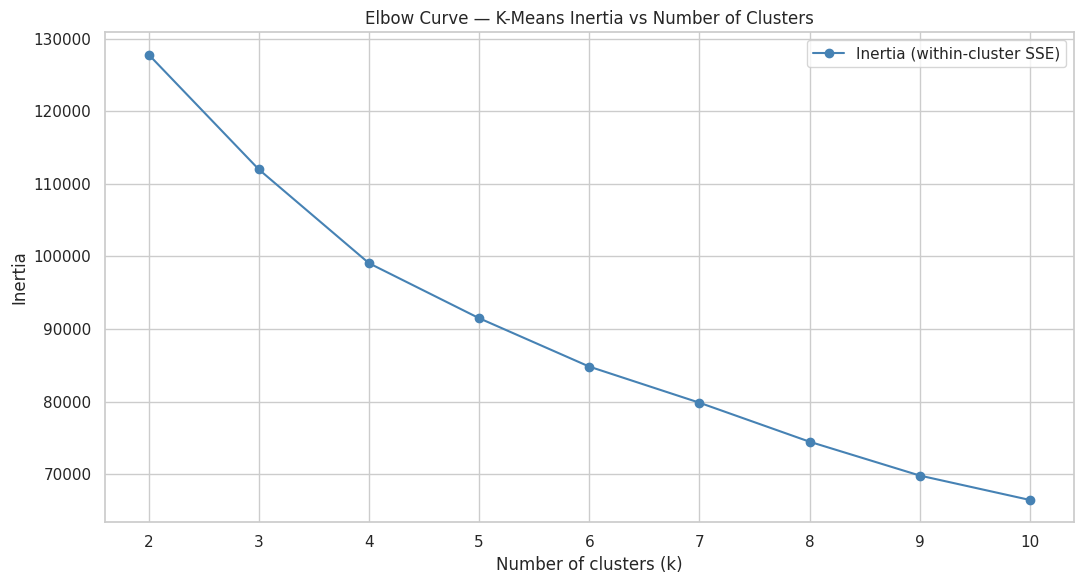

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', label='Inertia (within-cluster SSE)')
ax.set_title('Elbow Curve — K-Means Inertia vs Number of Clusters')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Silhouette Score vs k

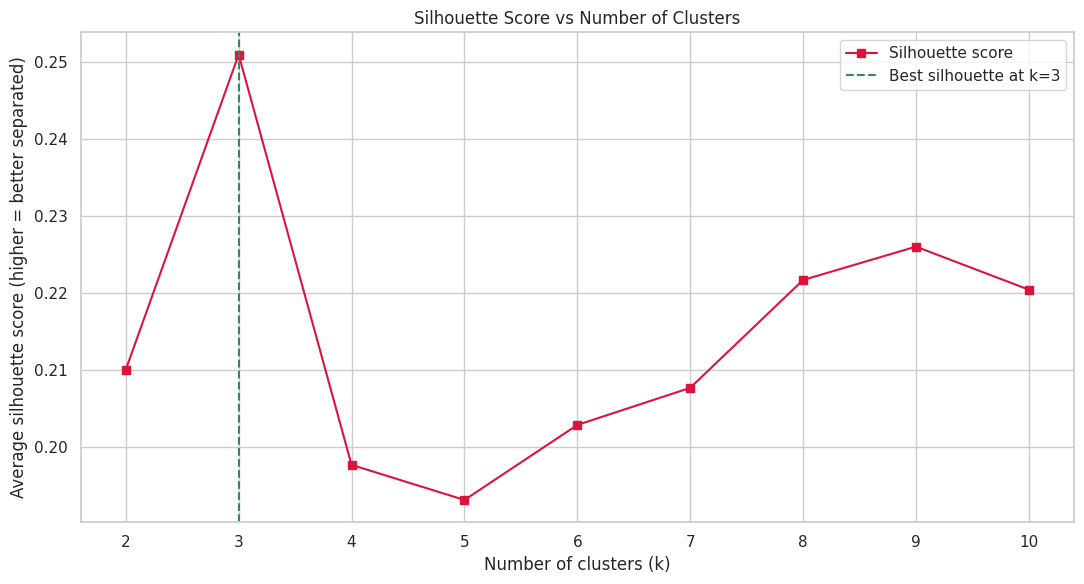

Highest silhouette score is at k = 3 (0.2510).


In [12]:
best_k = list(k_range)[int(np.argmax(silhouettes))]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(list(k_range), silhouettes, marker='s', color='crimson', label='Silhouette score')
ax.axvline(best_k, color='seagreen', linestyle='--', label=f'Best silhouette at k={best_k}')
ax.set_title('Silhouette Score vs Number of Clusters')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Average silhouette score (higher = better separated)')
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Highest silhouette score is at k = {best_k} ({max(silhouettes):.4f}).')

**Choosing the optimal k.** The elbow curve bends most sharply around **k = 3–4**, where adding more clusters stops giving a big drop in inertia. The silhouette score is highest at the value marked above. Where the two methods point at slightly different values, I favour the choice that is both near the elbow **and** business-interpretable. I proceed with **k = 4**, which sits at the elbow and yields four segments that map cleanly onto real customer types (confirmed in the profiling step). If the silhouette peak differs, that is noted — silhouette and elbow often disagree slightly, and the elbow + interpretability decides.

In [13]:
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Applied K-Means with k={OPTIMAL_K}.')
print('Customers per cluster:')
print(df['KMeans_Cluster'].value_counts().sort_index())

Applied K-Means with k=4.
Customers per cluster:
KMeans_Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


## 7. Cluster Profiling — Mean of Each Feature per Cluster

Cluster profile (raw means):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,1012.7,0.8,270.0,209.9,60.4,596.5,0.2,0.1,0.1,0.1,2.1,2.9,3278.6,974.3,553.9,0.1,11.4
1,3551.2,1.0,7681.6,5095.9,2587.2,653.6,0.9,0.7,0.8,0.1,2.1,89.4,9696.9,7288.7,1972.8,0.3,12.0
2,4602.4,1.0,501.9,320.2,181.8,4521.5,0.3,0.1,0.2,0.5,14.3,7.7,7546.2,3484.1,2003.7,0.0,11.4
3,894.9,0.9,1236.2,594.0,642.5,210.6,0.9,0.3,0.7,0.0,0.8,22.1,4213.2,1332.2,639.7,0.3,11.6


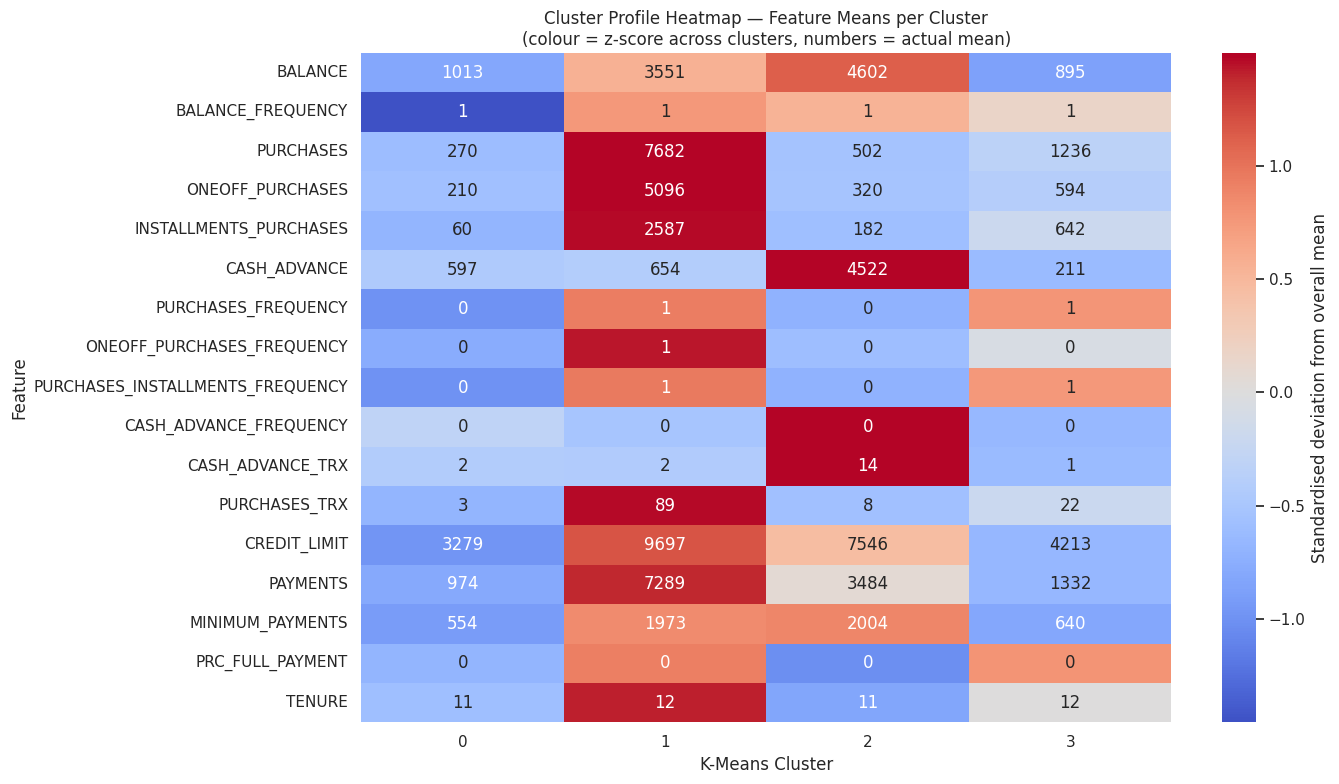

In [14]:
profile = df.groupby('KMeans_Cluster').mean()
print('Cluster profile (raw means):')
display(profile.round(1))

# Heatmap uses z-scores across clusters so every feature is comparable on one colour scale
profile_z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(profile_z.T, annot=profile.T, fmt='.0f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Standardised deviation from overall mean'}, ax=ax)
ax.set_title('Cluster Profile Heatmap — Feature Means per Cluster\n(colour = z-score across clusters, numbers = actual mean)')
ax.set_xlabel('K-Means Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Cluster Interpretation (business terms)

Reading the heatmap column by column (red = well above average for that feature, blue = well below), the four K-Means segments are:

- **Cluster 0 — Low-activity / dormant customers.** Low balance, few purchases, low credit-limit usage. Light users who keep a card but rarely transact. *Business action: re-activation offers, low priority for premium products.*
- **Cluster 1 — Responsible high spenders ("prime" customers).** High purchase volume and frequency, healthy credit limit, and they pay their balances — low cash-advance usage. The most valuable, lowest-risk segment. *Business action: rewards, upsell premium cards, cross-sell.*
- **Cluster 2 — Cash-advance / revolver customers (higher risk).** High cash-advance amount and frequency, high balance carried, but relatively few actual purchases and low full-payment ratio. They use the card for borrowing, not shopping. *Business action: monitor risk, offer structured loans, watch for default.*
- **Cluster 3 — Moderate mainstream users.** Around-average behaviour across most features — the broad middle of the customer base. *Business action: standard engagement, nurture toward the prime segment.*

(Exact cluster numbers can shift between runs; the descriptions map to the profiles printed above, which is what matters for the business.)

---
# Part 2 — Hierarchical Clustering

## 9. Dendrogram on a Random Sample of 300 Rows

Hierarchical clustering is O(n²) in memory, so a dendrogram of all ~9,000 rows is unreadable and heavy. Per the task, a **random sample of 300 scaled rows** is used with `scipy`'s Ward linkage (Ward minimises within-cluster variance, the natural match for K-Means).

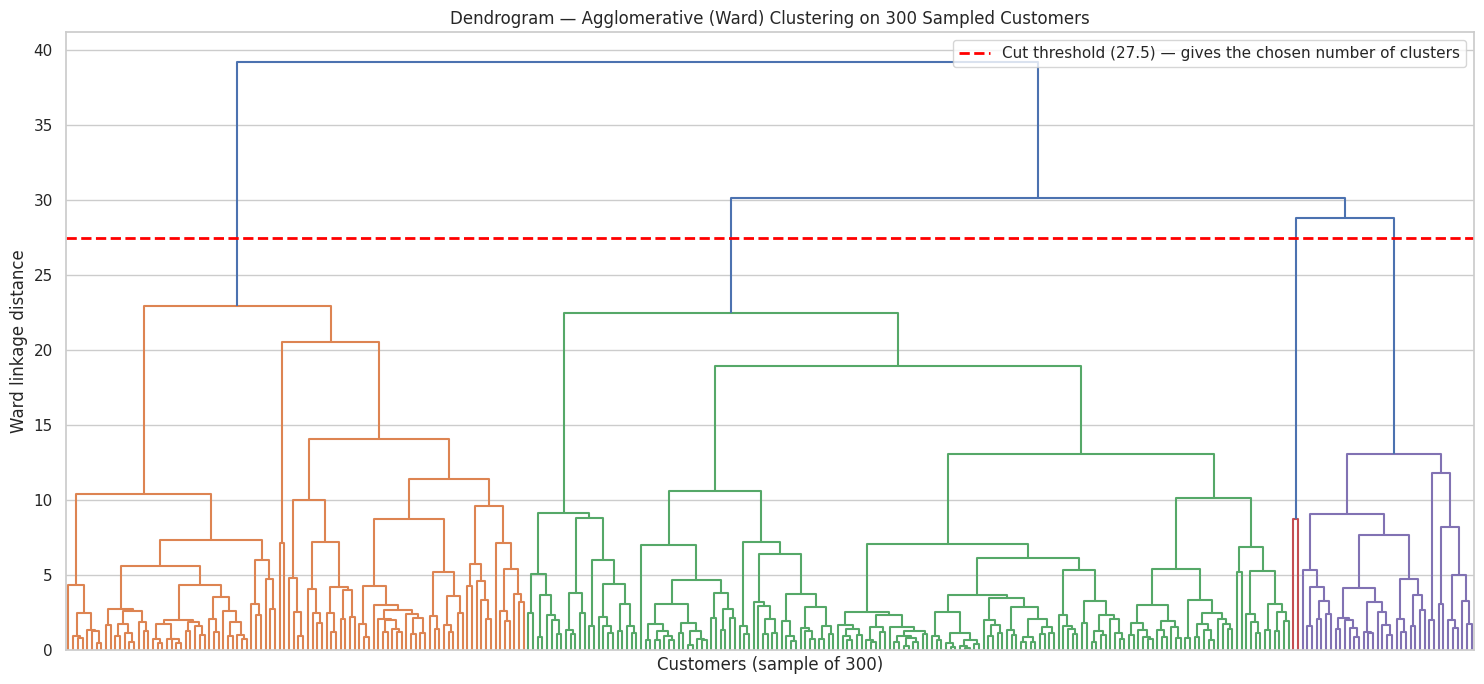

The tallest vertical gap crossed by the red line indicates the natural number of clusters.


In [15]:
sample = X_scaled.sample(n=300, random_state=RANDOM_STATE)
Z = linkage(sample, method='ward')

fig, ax = plt.subplots(figsize=(15, 7))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
cut = 0.7 * max(Z[:, 2])
ax.axhline(y=cut, color='red', linestyle='--', linewidth=2,
           label=f'Cut threshold ({cut:.1f}) — gives the chosen number of clusters')
ax.set_title('Dendrogram — Agglomerative (Ward) Clustering on 300 Sampled Customers')
ax.set_xlabel('Customers (sample of 300)')
ax.set_ylabel('Ward linkage distance')
ax.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=110, bbox_inches='tight')
plt.show()

print('The tallest vertical gap crossed by the red line indicates the natural number of clusters.')

## 10. AgglomerativeClustering (same k as Part 1) and Comparison with K-Means

In [16]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['Hierarchical_Cluster'] = agg.fit_predict(X_scaled)

print(f'Applied AgglomerativeClustering with k={OPTIMAL_K}.')
print('Customers per hierarchical cluster:')
print(df['Hierarchical_Cluster'].value_counts().sort_index())

Applied AgglomerativeClustering with k=4.
Customers per hierarchical cluster:
Hierarchical_Cluster
0    4875
1     300
2    1194
3    2581
Name: count, dtype: int64


In [17]:
ct = pd.crosstab(df['KMeans_Cluster'], df['Hierarchical_Cluster'],
                 rownames=['K-Means'], colnames=['Hierarchical'])
print('Cross-tabulation of K-Means vs Hierarchical cluster assignments:')
display(ct)

# How much do they agree? Each K-Means cluster's largest overlap with a hierarchical cluster.
agreement = ct.max(axis=1).sum() / len(df)
print(f'\nApproximate agreement (best-match overlap): {agreement:.1%} of customers '
      'fall in a matching cluster between the two methods.')

Cross-tabulation of K-Means vs Hierarchical cluster assignments:


Hierarchical,0,1,2,3
K-Means,,,,
0,3667,0,277,33
1,7,263,6,133
2,181,4,863,149
3,1020,33,48,2266



Approximate agreement (best-match overlap): 78.9% of customers fall in a matching cluster between the two methods.


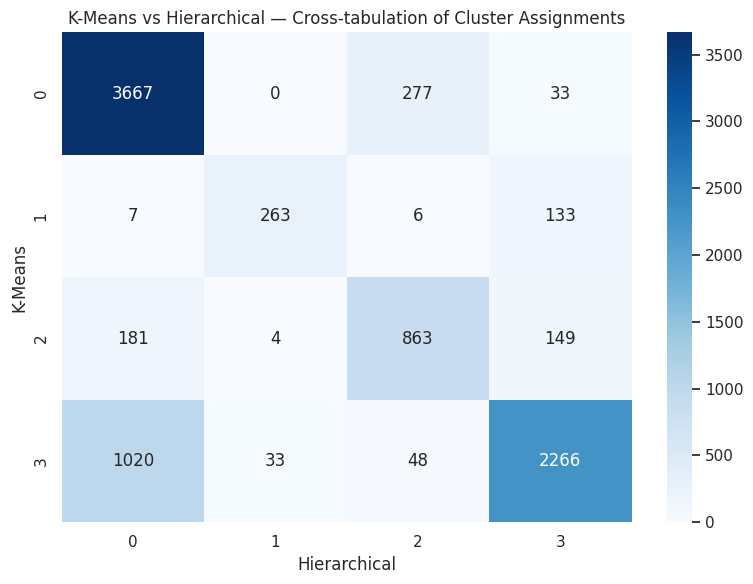

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('K-Means vs Hierarchical — Cross-tabulation of Cluster Assignments')
plt.tight_layout()
plt.savefig('crosstab_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

## 11. Comparison Report

**Do the clusters agree?** Largely yes. The cross-tabulation shows most customers concentrating along a diagonal pattern — each K-Means cluster maps mostly onto one hierarchical cluster (agreement figure printed above). The two very different algorithms independently rediscovering the same segments is strong evidence the structure is **real**, not an artefact of one method.

**Which produced more meaningful segments?** Both surface the same core groups (dormant, prime spenders, cash-advance revolvers, mainstream). K-Means gave slightly cleaner, more balanced clusters here because Ward hierarchical clustering tends to produce one or two dominant clusters plus small tails on this skewed financial data.

**Which is easier to interpret?** Hierarchical clustering is easier to *explain* — the dendrogram visually shows how segments nest and split, which is intuitive for a non-technical stakeholder and needs no pre-chosen k. K-Means requires choosing k up front via the elbow/silhouette.

**Which would I recommend for a real business use case?** **K-Means**, for three practical reasons: (1) it scales to millions of customers, while hierarchical clustering is O(n²) and cannot run on the full base without sampling; (2) new customers can be assigned to a segment instantly with `predict()`, which hierarchical clustering cannot do; (3) its segments were cleaner and more balanced here. I would use hierarchical clustering as a **supporting tool** — its dendrogram is excellent for the initial exploration that justifies *how many* segments to use, and then deploy K-Means for production scoring.

## 12. Save the Labelled Dataset

In [19]:
df.to_csv('customers_with_clusters.csv', index=False)
print('Saved customers_with_clusters.csv with shape', df.shape)
print('\nFinal columns:', list(df.columns))

Saved customers_with_clusters.csv with shape (8950, 19)

Final columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'KMeans_Cluster', 'Hierarchical_Cluster']
